- Telecom company wants to identify customers who are likely to churn (leave the service).
By predicting churn in advance, the company can take retention actions such as targeted offers, customer engagement, and service improvement.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df =pd.read_csv('Sales_details.csv')
df

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,BSNL,F,19,Tamil Nadu,Delhi,326273,2020-01-05,0,81532,29,36,3952,0
996,997,Airtel,M,38,Nagaland,Kolkata,126707,2020-01-05,4,127367,39,19,5328,0
997,998,Vodafone,M,18,Odisha,Chennai,742600,2020-01-05,1,120764,49,42,6260,1
998,999,Vodafone,M,64,Tripura,Delhi,186458,2020-01-05,1,95036,96,12,2262,0


In [3]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [4]:
df.tail()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
995,996,BSNL,F,19,Tamil Nadu,Delhi,326273,2020-01-05,0,81532,29,36,3952,0
996,997,Airtel,M,38,Nagaland,Kolkata,126707,2020-01-05,4,127367,39,19,5328,0
997,998,Vodafone,M,18,Odisha,Chennai,742600,2020-01-05,1,120764,49,42,6260,1
998,999,Vodafone,M,64,Tripura,Delhi,186458,2020-01-05,1,95036,96,12,2262,0
999,1000,Reliance Jio,M,38,Himachal Pradesh,Bangalore,378040,2020-01-06,4,88151,29,25,5908,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   customer_id           1000 non-null   int64 
 1   telecom_partner       1000 non-null   object
 2   gender                1000 non-null   object
 3   age                   1000 non-null   int64 
 4   state                 1000 non-null   object
 5   city                  1000 non-null   object
 6   pincode               1000 non-null   int64 
 7   date_of_registration  1000 non-null   object
 8   num_dependents        1000 non-null   int64 
 9   estimated_salary      1000 non-null   int64 
 10  calls_made            1000 non-null   int64 
 11  sms_sent              1000 non-null   int64 
 12  data_used             1000 non-null   int64 
 13  churn                 1000 non-null   int64 
dtypes: int64(9), object(5)
memory usage: 109.5+ KB


In [6]:
df.describe()

,customer_id,age,pincode,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,45.400000,555700.688000,1.937000,84397.693000,48.846000,24.51200,4826.720000,0.179000
std,288.819436,16.390077,257620.890154,1.402497,36449.528961,29.326069,14.84912,2955.244989,0.383544
min,1.000000,18.000000,100027.000000,0.000000,20038.000000,-10.000000,-4.00000,-884.000000,0.000000
25%,250.750000,31.000000,334693.750000,1.000000,52110.750000,25.000000,12.00000,2412.750000,0.000000
50%,500.500000,45.000000,558293.500000,2.000000,85930.000000,47.000000,25.00000,4720.000000,0.000000
75%,750.250000,60.000000,779263.750000,3.000000,114979.000000,73.250000,37.00000,7286.500000,0.000000
max,1000.000000,74.000000,999941.000000,4.000000,149940.000000,107.000000,53.00000,10854.000000,1.000000


In [7]:
df.isnull().sum()


customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

- Missing values were examined to ensure data quality before preprocessing.

In [8]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn'],
      dtype='object')

In [9]:
df['churn'].value_counts()


churn
0    821
1    179
Name: count, dtype: int64

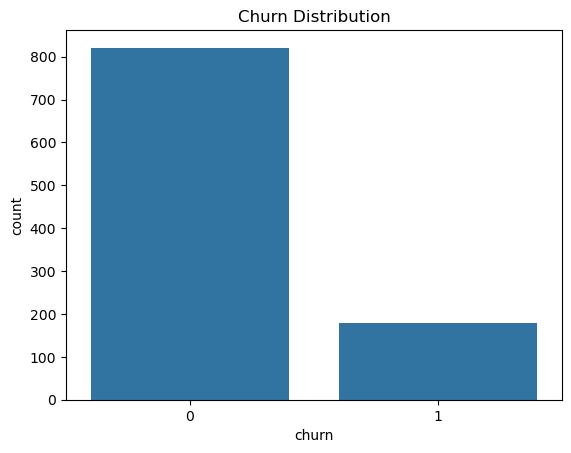

In [10]:
sns.countplot(x='churn', data=df)
plt.title("Churn Distribution")
plt.show()


- The dataset shows class imbalance, which may require handling techniques such as SMOTE or class_weight adjustment.

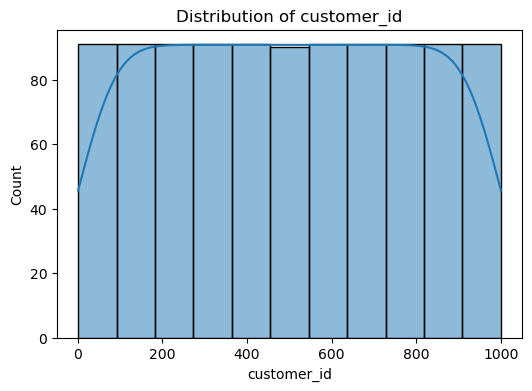

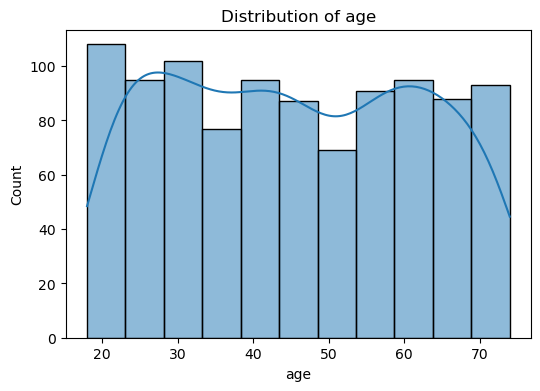

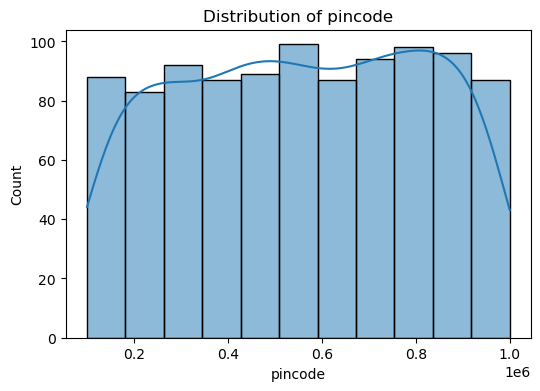

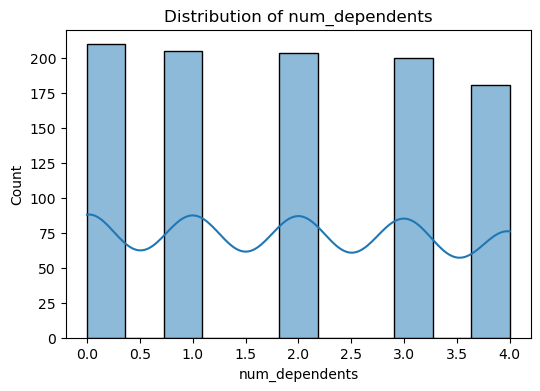

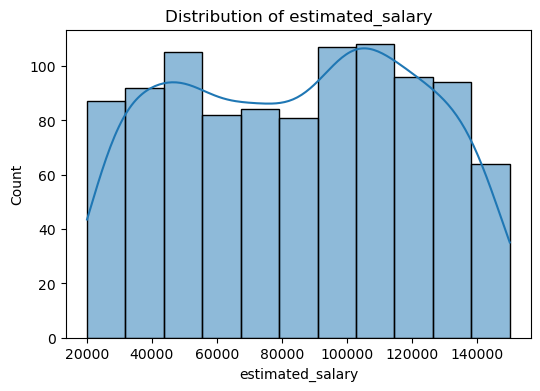

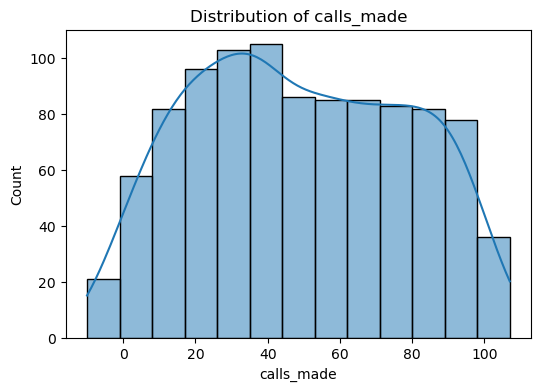

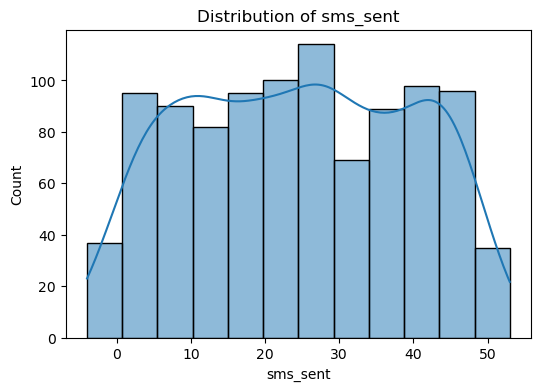

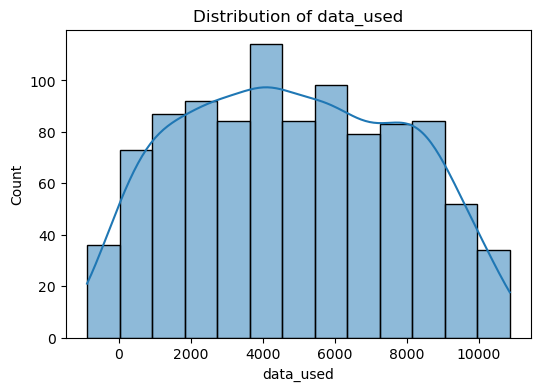

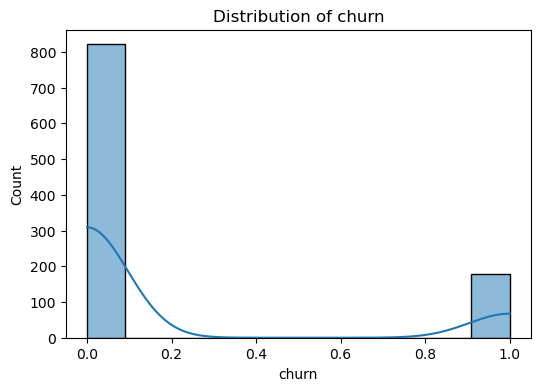

In [11]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


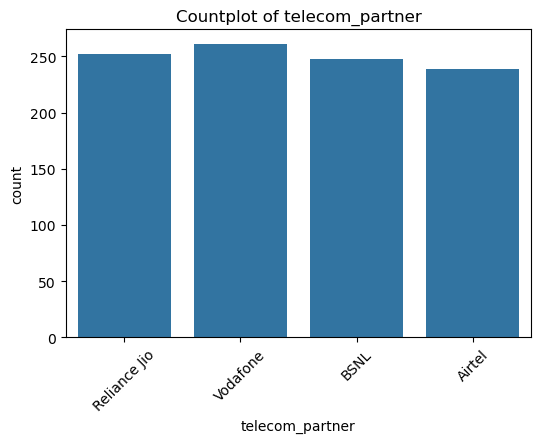

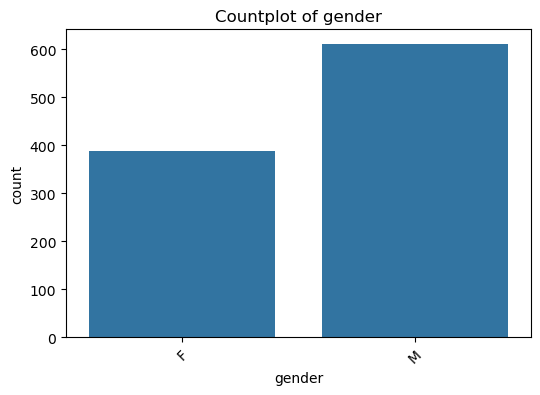

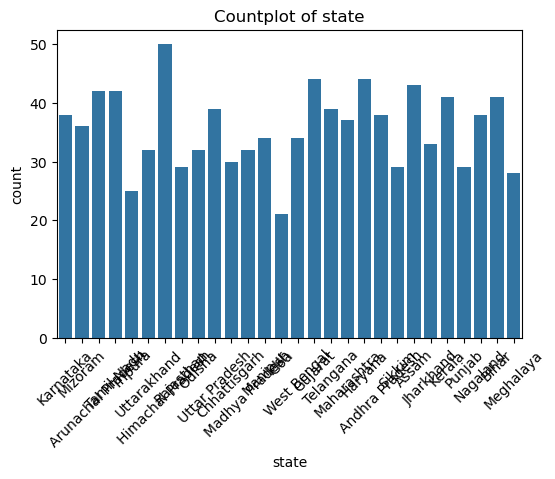

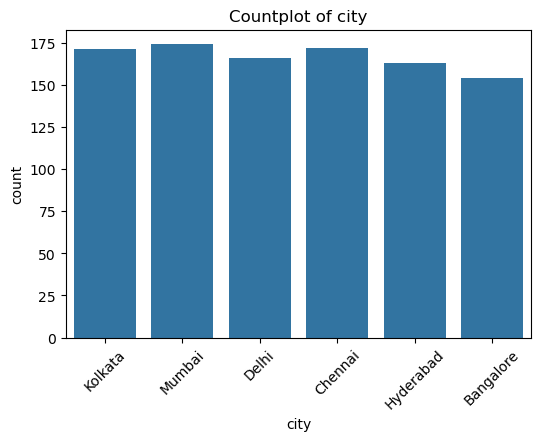

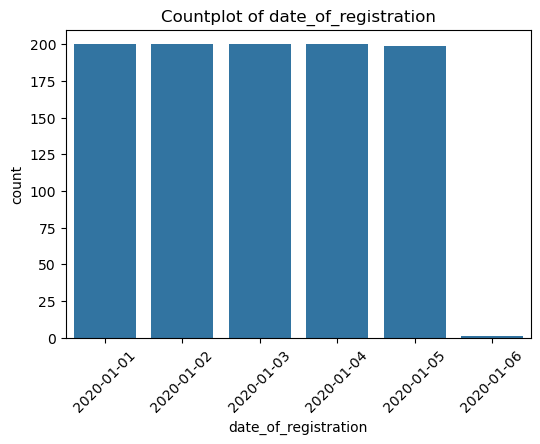

In [12]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(f"Countplot of {col}")
    plt.show()


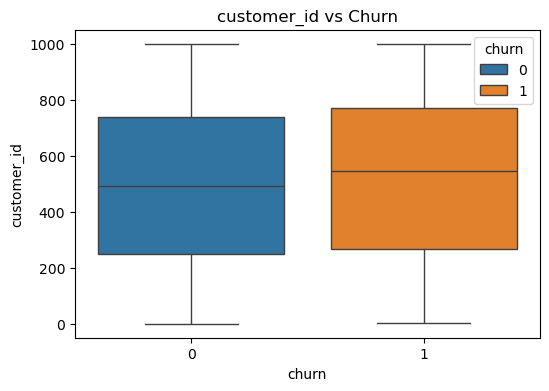

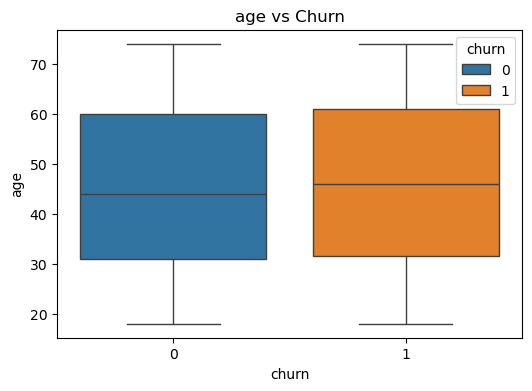

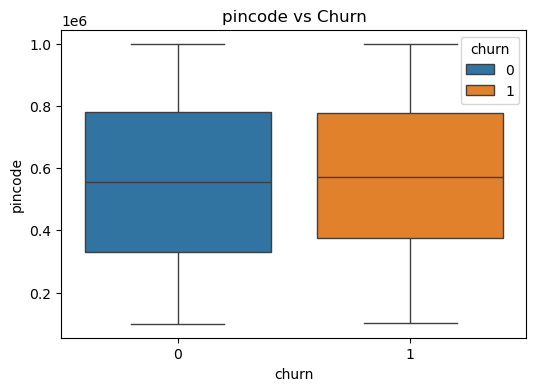

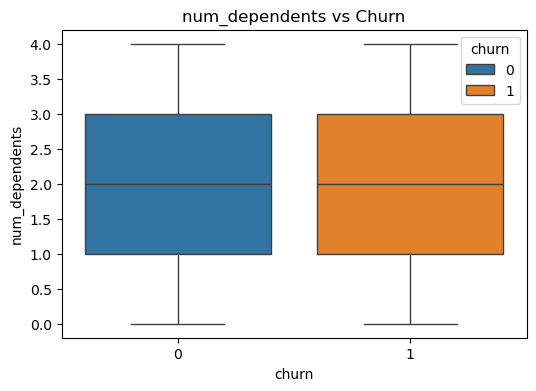

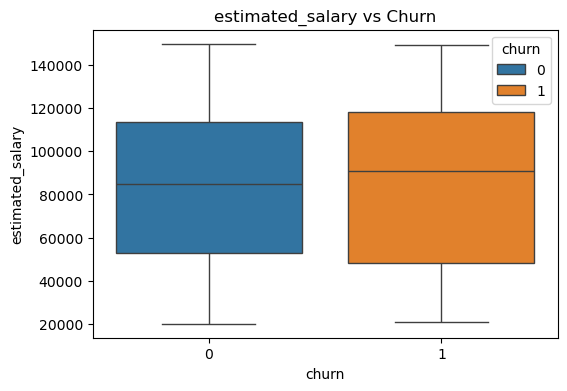

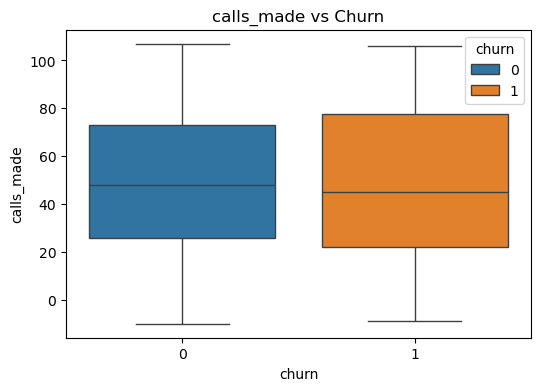

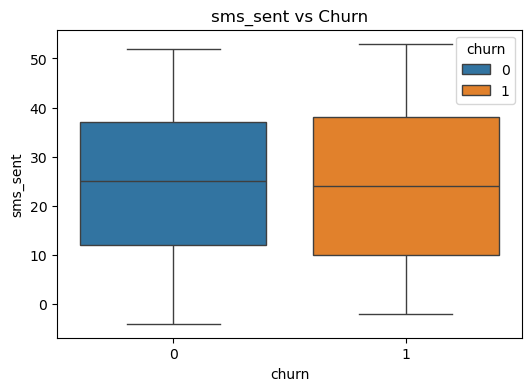

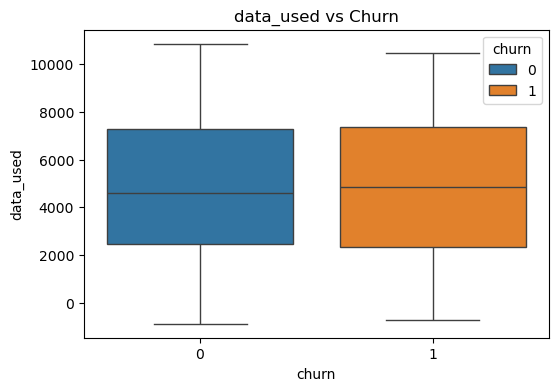

In [13]:
for col in num_cols:
    if col != 'churn':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='churn', y=col, data=df, hue='churn')
        plt.title(f"{col} vs Churn")
        plt.show()
